Método das diferenças finitas linear:

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [29]:
def p(x):
    return -2/x

def q(x):
    return 2/(x**2)

def r(x):
    return np.sin(np.log(x))/(x**2)

c2 = 1/(70) * (8 - 12*np.sin(np.log(2)) - 4*np.cos(np.log(2)))
c1 = 11/10 - c2
def real_f(x):
    return c1*x + c2/(x**2) - (3/10) * np.sin(np.log(x)) - (1/10)*np.cos(np.log(x))

In [30]:
def thomas_algorithm(a,b,d,B,ti,tf,h,alpha,beta):
    N = len(b)
    y = np.zeros(N)
    a[0] = a[0]/d[0]
    B[0] = B[0]/d[0]

    for i in range(1, N - 1):
        a[i]  = a[i] / (d[i] - b[i]*a[i - 1])
        B[i] = (B[i] - b[i]*B[i - 1]) / (d[i] - b[i]*a[i - 1])

    B[N - 1] = (B[N - 1] - b[N - 1]*B[N - 2]) / (d[N - 1] - b[N - 1]*a[N - 2])
    y[N - 1] = B[N - 1]

    for i in range(N - 2, -1, -1):
        y[i] = B[i] - a[i]*y[i + 1]

    return y

In [31]:
def diferencas_finitas(ti,tf,h,alpha,beta,p,q,r):
    N = int(np.round((tf - ti)/h))
    t = np.linspace(ti,tf,N + 1)
    n_sistema = (N + 1) - 2

    y = np.zeros(N + 1)
    a = np.zeros(n_sistema) #Diagonal principal
    b = np.zeros(n_sistema) #Diagonal superior
    d = np.zeros(n_sistema) #Resultados
    c = np.zeros(n_sistema) #Diagonal inferior

    a[0] = 2 + (h**2) * q(t[1])
    b[0] = -1 + (h/2)* p(t[1])
    d[0] = -(h**2)*r(t[1]) + (1 + (h/2)*p(t[1]))*alpha

    for i in range(1, n_sistema - 1):
        a[i] = 2 + (h**2)*q(t[i + 1])
        b[i] = -1 + (h/2)*p(t[i + 1])
        c[i] = -1 - (h/2)*p(t[i + 1])
        d[i] = -(h**2)*r(t[i + 1])

    a[n_sistema - 1] = 2 + (h**2)*q(t[N - 1])
    c[n_sistema - 1] = -1 -(h / 2)*p(t[N - 1])
    d[n_sistema - 1] = -(h**2)*r(t[N - 1]) + (1 - (h/2)*p(t[N - 1]))*beta

    #Algorítmo de Thomas
    y[0] = alpha
    y[-1] = beta
    y[1:-1] = thomas_algorithm(b,c,a,d,ti,tf,h,alpha,beta)

    return t,y

In [32]:
t_1,y_1= diferencas_finitas(1,2,0.1,1,2,p,q,r)

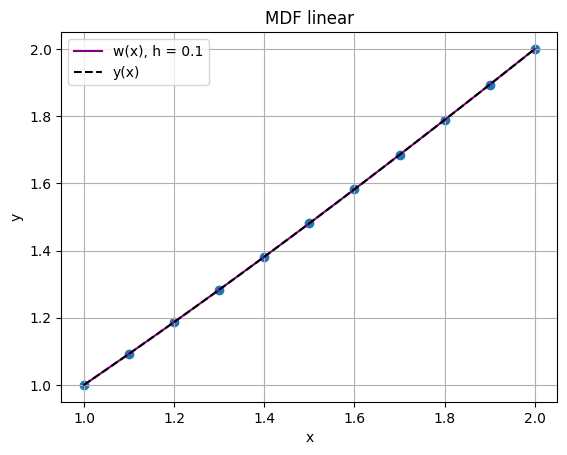

In [35]:
t_real = np.linspace(1,2)
plt.plot(t_1,y_1, label = f"w(x), h = {0.1}", color = '#800080')
plt.plot(t_real,real_f(t_real), label = "y(x)", linestyle = '--', color = "black")
plt.title("MDF linear")
plt.xlabel("x")
plt.ylabel("y")
plt.scatter(t_1,y_1)
plt.legend()
plt.grid()
plt.show()